In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import pytensor.tensor as pt
from scipy.stats import gaussian_kde


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
flat_df = pd.read_csv('SCPT_Param_Qtncs.csv')

# Sort the DataFrame by travelTimeMeta_ID and ztop_TT
flat_df = flat_df.sort_values(by=['travelTimeMeta_ID', 'ztop_TT'])

tt_ids = flat_df['travelTimeMeta_ID']
Qtncs_raw = flat_df['Qtn_TT']
Vsi_raw = flat_df['Vsi']
Ic_raw = flat_df['Ic_TT']
fz_raw = flat_df['fz_TT']
ztop_raw = flat_df['ztop_TT']
zbot_raw = flat_df['zbot_TT']
group_ids = flat_df['Group_ID']

valid_indices = (Vsi_raw > 50) & (Vsi_raw < 1000) & (fz_raw > 0) & (Qtncs_raw > 0) & (Ic_raw < 4.0)

tt_ids = np.asarray(tt_ids[valid_indices])
Qtncs = np.asarray(Qtncs_raw[valid_indices])
Vsi = np.asarray(Vsi_raw[valid_indices])
Ic = np.asarray(Ic_raw[valid_indices])
fz = np.asarray(fz_raw[valid_indices])
ztop = np.asarray(ztop_raw[valid_indices])
zbot = np.asarray(zbot_raw[valid_indices])
group_ids = np.asarray(group_ids[valid_indices])

In [3]:
# create a unique layer ID for each layer
layer_ids = np.arange(len(tt_ids))

In [4]:
flat_comp_df = pd.read_csv("SCPT_Vs_comp.csv")

# Sort the DataFrame by travelTimeMeta_ID and CPT_depth

tt_ids_CPT = np.asarray(flat_comp_df['travelTimeMeta_ID'])
CPT_depth = np.asarray(flat_comp_df['CPT_depth'])
fz_CPT = np.asarray(flat_comp_df['fz_CPT'])
Ic_CPT = np.asarray(flat_comp_df['Ic_CPT'])
Qtncs_CPT = np.asarray(flat_comp_df['Qtncs_CPT'])
group_ids_CPT = np.asarray(flat_comp_df['Group_ID'])

In [5]:
# Output array
lay_id_assign = np.full(len(CPT_depth), -1)

# Vectorized matching
for i in range(len(layer_ids)):

    mask = (
        (tt_ids_CPT == tt_ids[i]) &
        (CPT_depth >= ztop[i]) &
        (CPT_depth < zbot[i])
    )

    lay_id_assign[mask] = layer_ids[i]

In [6]:
index = (lay_id_assign > -0.1) & (Qtncs_CPT > 0) & (fz_CPT > 0) & (Ic_CPT < 4.0) 
tt_ids_CPT_valid = tt_ids_CPT[index]
CPT_depth_valid = CPT_depth[index]
fz_CPT_valid = fz_CPT[index]
Ic_CPT_valid = Ic_CPT[index]
Qtncs_CPT_valid = Qtncs_CPT[index]

lay_id_assign_valid = lay_id_assign[index]
group_ids_CPT_valid = np.asarray(group_ids_CPT[index])

In [7]:
# create filter for each group
unique_groups = np.unique(group_ids_CPT_valid)
group_filter = {group: (group_ids_CPT_valid == group) for group in unique_groups}

Geology_1 = group_filter[1]
Geology_2 = group_filter[2]
Geology_3 = group_filter[3]
Geology_4 = group_filter[4]
Geology_5 = group_filter[5]
Geology_6 = group_filter[6]
Geology_7 = group_filter[7]
Geology_8 = group_filter[8]
Geology_9 = group_filter[9]
Geology_10 = group_filter[10]
Geology_11 = group_filter[11]

In [8]:
Y = Vsi
X1 = Qtncs_CPT_valid
X2 = fz_CPT_valid
X3 = Ic_CPT_valid

# Profile_ID = np.copy(tt_ids_CPT_valid)
Profile_ID = np.copy(tt_ids)

Profile_ID_unique, Profile_ID = np.unique(Profile_ID, return_inverse = True)

In [9]:
# Inputs
lnY = np.log(Y)
lnX1 = np.log(X1)
lnX2 = np.log(X2)

# g_id = len(Group_ID_unique)
p_id = len(Profile_ID_unique)

with pm.Model() as model:

    # Fixed effects
    b1 = pm.Normal("b1", mu=0.2, sigma=1)
    b2 = pm.Normal("b2", mu=3.4, sigma=1)
    b3 = pm.Normal("b3", mu=2.6, sigma=1)
    
    a1 = pm.Normal("a1", mu=4.0, sigma=1)
    a2 = pm.Normal("a2", mu=4.0, sigma=1)
    a3 = pm.Normal("a3", mu=4.0, sigma=1)
    a4 = pm.Normal("a4", mu=4.0, sigma=1)
    a5 = pm.Normal("a5", mu=4.0, sigma=1)
    a6 = pm.Normal("a6", mu=4.0, sigma=1)
    a7 = pm.Normal("a7", mu=4.0, sigma=1)
    a8 = pm.Normal("a8", mu=4.0, sigma=1)
    a9 = pm.Normal("a9", mu=4.0, sigma=1)
    a10 = pm.Normal("a10", mu=4.0, sigma=1)
    a11 = pm.Normal("a11", mu=4.0, sigma=1)

    # Random effect std
    sigma_p = pm.HalfNormal("sigma_p", sigma=1)
    eta_p = pm.Normal("eta_p", mu = 0, sigma = 1, shape = p_id)

    # Residual std
    eps = pm.HalfNormal("eps", sigma=1)
    
    # Total residual
    sigma = pt.sqrt(eps ** 2 + sigma_p ** 2)
    
    f_Ic = 0.1 + 0.4  / (1 + pt.exp(-b2 * (X3 - b3)))
    # f_Ic = 0.1 + 0.4 * (1 / (1 + np.exp(- 3.98433191 * (Ic_CPT_valid - 2.5189692))))
    

    cpt_velocity = b1 * lnX1 + f_Ic * lnX2 + a1 * Geology_1 + a2 * Geology_2 + a3 * Geology_3 + a4 * Geology_4 + a5 * Geology_5 + a6 * Geology_6 + a7 * Geology_7 + a8 * Geology_8 + a9 * Geology_9 + a10 * Geology_10 + a11 * Geology_11 

    cpt_slowness = 1.0 / pt.exp(cpt_velocity)
    
    dz = pt.full(cpt_velocity.shape, 0.05)
    
    layer_slowness = pt.bincount(lay_id_assign_valid, weights=cpt_slowness * dz)
    layer_thickness = pt.bincount(lay_id_assign_valid, weights=dz)
    
    mu = pt.log(layer_thickness / layer_slowness) + eta_p[Profile_ID]
    
    mu2 = pt.log(layer_thickness / layer_slowness)
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu = mu, sigma = eps, observed = lnY) + pm.Normal("y_obs2", mu = mu2, sigma = sigma, observed = lnY)

    # Sampling
    # trace = pm.sample(draws = 1000, tune=1000, chains = 4, cores = 1)
    
    start = {"b1": 0.2, 
             "b2": 3.4, 
             "b3": 2.6, 
             "a1": 4.1, 
             "a2": 4.1, 
             "a3": 4.1, 
             "a4": 4.1, 
             "a5": 4.1, 
             "a6": 4.1, 
             "a7": 4.1, 
             "a8": 4.1, 
             "a9": 4.1, 
             "a10": 4.1, 
             "a11": 4.1, 
             "sigma_p": 0.13, 
             "eps": 0.2, 
             "eta_p": np.zeros(p_id)}
    
    MAP = pm.find_MAP(start = start, method="L-BFGS-B")
    


In [10]:
MAP

{'b1': array(0.24349142),
 'b2': array(2.45936531),
 'b3': array(2.49278923),
 'a1': array(4.35008377),
 'a2': array(4.21851338),
 'a3': array(4.16445671),
 'a4': array(4.15688533),
 'a5': array(4.19081863),
 'a6': array(4.21670691),
 'a7': array(4.30038329),
 'a8': array(4.36801207),
 'a9': array(4.30474051),
 'a10': array(4.52692817),
 'a11': array(4.35213713),
 'sigma_p_log__': array(-2.04270802),
 'eta_p': array([-0.16932038, -0.14212388, -0.22222145, ...,  0.07650599,
         0.02138638,  0.12732349]),
 'eps_log__': array(-1.64040642),
 'sigma_p': array(0.12967707),
 'eps': array(0.19390122)}

In [17]:
with model: 
    start = MAP 
    trace = pm.sample(draws = 1000, tune=1000, chains = 4, cores = 4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b1, b2, b3, a1, a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, sigma_p, eta_p, eps]


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12906 seconds.


In [26]:
import arviz as az
                               
az.summary(trace, var_names=["b1", "b2", "b3", "a1", "a2", "a3", "a4", "a5", "a6", "a7", "a8", "a9", "a10", "a11"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b1,0.243,0.003,0.237,0.250,0.000,0.000,571.0,938.0,1.0
b2,2.458,0.111,2.253,2.667,0.001,0.001,6636.0,3201.0,1.0
b3,2.497,0.015,2.469,2.525,0.000,0.000,4300.0,3387.0,1.0
a1,4.350,0.017,4.316,4.382,0.001,0.000,602.0,1155.0,1.0
a2,4.219,0.017,4.187,4.250,0.001,0.000,590.0,1006.0,1.0
a3,4.164,0.018,4.130,4.197,0.001,0.000,681.0,1402.0,1.0
a4,4.157,0.021,4.119,4.198,0.001,0.001,795.0,1386.0,1.0
a5,4.191,0.019,4.153,4.225,0.001,0.001,655.0,1085.0,1.0
a6,4.217,0.017,4.185,4.250,0.001,0.000,696.0,1142.0,1.0
a7,4.300,0.019,4.266,4.335,0.001,0.000,701.0,1221.0,1.0


In [24]:
az.summary(trace, var_names=["sigma_p", "eps"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_p,0.108,0.005,0.098,0.117,0.0,0.0,4782.0,2811.0,1.0
eps,0.207,0.002,0.204,0.210,0.0,0.0,3974.0,2727.0,1.0


In [25]:
import pickle

with open("trace.pkl", "wb") as f:
    pickle.dump(trace, f)

In [9]:
import pickle

with open("trace.pkl", "rb") as f:
    trace = pickle.load(f)

In [11]:
phi_p = trace.posterior["sigma_p"].mean(dim=("chain", "draw"))
phi_ep = trace.posterior["eps"].mean(dim=("chain", "draw"))

In [12]:
sig = np.sqrt(phi_p ** 2 + phi_ep ** 2)
print (sig)

<xarray.DataArray ()> Size: 8B
array(0.23334009)


In [13]:
eta_p_mean = trace.posterior["eta_p"].mean(dim=("chain", "draw"))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b1,0.243,0.003,0.237,0.249,0.000,0.000,611.0,1275.0,1.01
b2,2.459,0.111,2.273,2.683,0.001,0.001,5927.0,2975.0,1.00
b3,2.498,0.015,2.470,2.528,0.000,0.000,5100.0,2819.0,1.00
a1,4.352,0.017,4.321,4.383,0.001,0.000,664.0,1597.0,1.00
a2,4.220,0.017,4.191,4.253,0.001,0.000,631.0,1406.0,1.01
...,...,...,...,...,...,...,...,...,...
eta_p[1167],0.077,0.084,-0.078,0.232,0.001,0.001,8226.0,3155.0,1.01
eta_p[1168],0.022,0.076,-0.118,0.168,0.001,0.001,8144.0,2634.0,1.00
eta_p[1169],0.130,0.093,-0.050,0.302,0.001,0.001,8919.0,2788.0,1.01
sigma_p,0.108,0.005,0.099,0.116,0.000,0.000,4663.0,2490.0,1.00


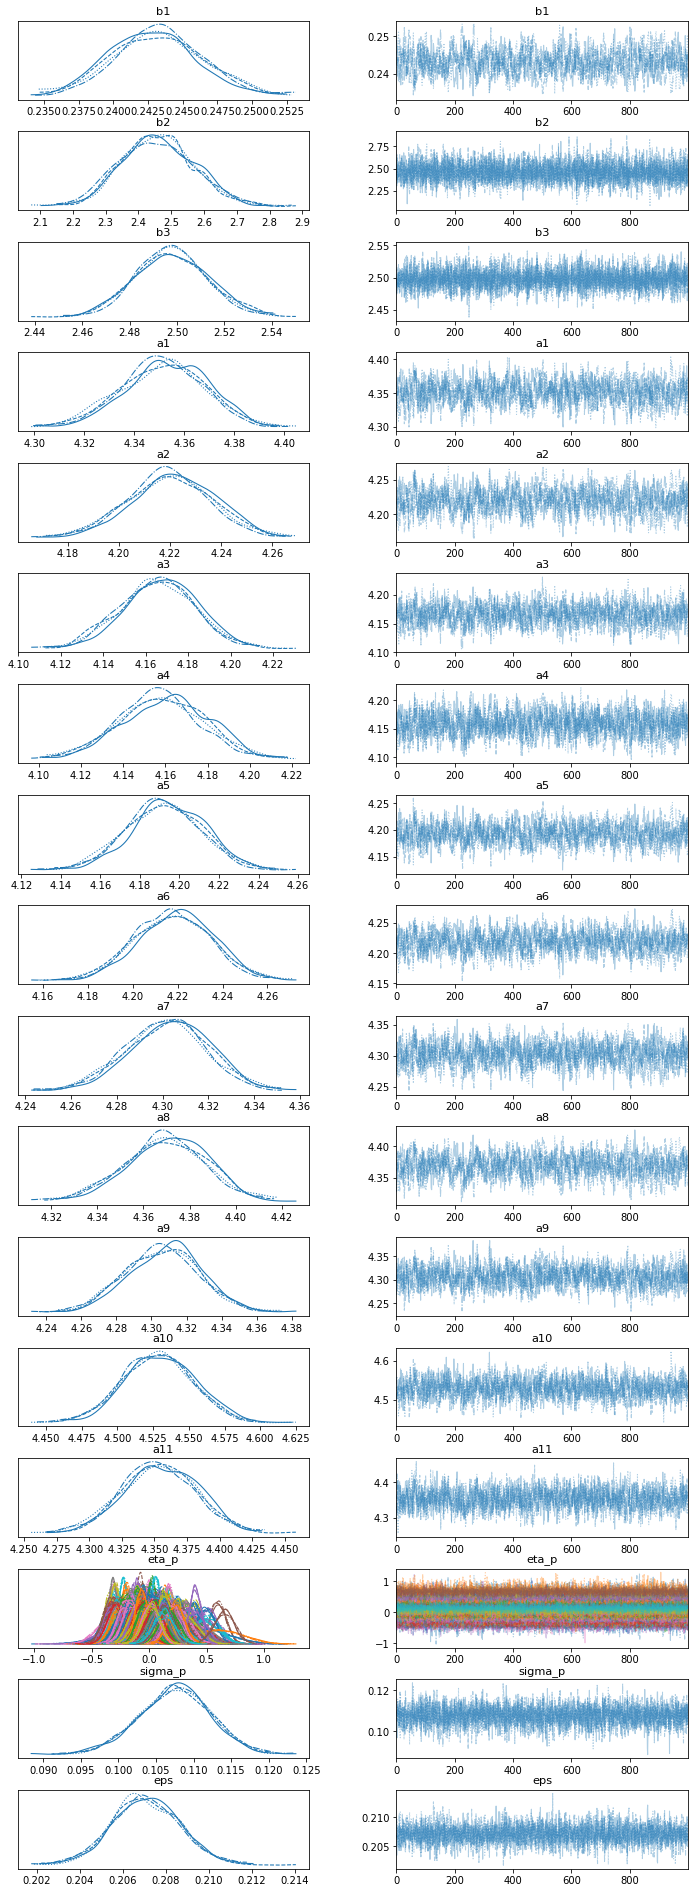

In [17]:
az.plot_trace(trace)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
az.summary(trace)

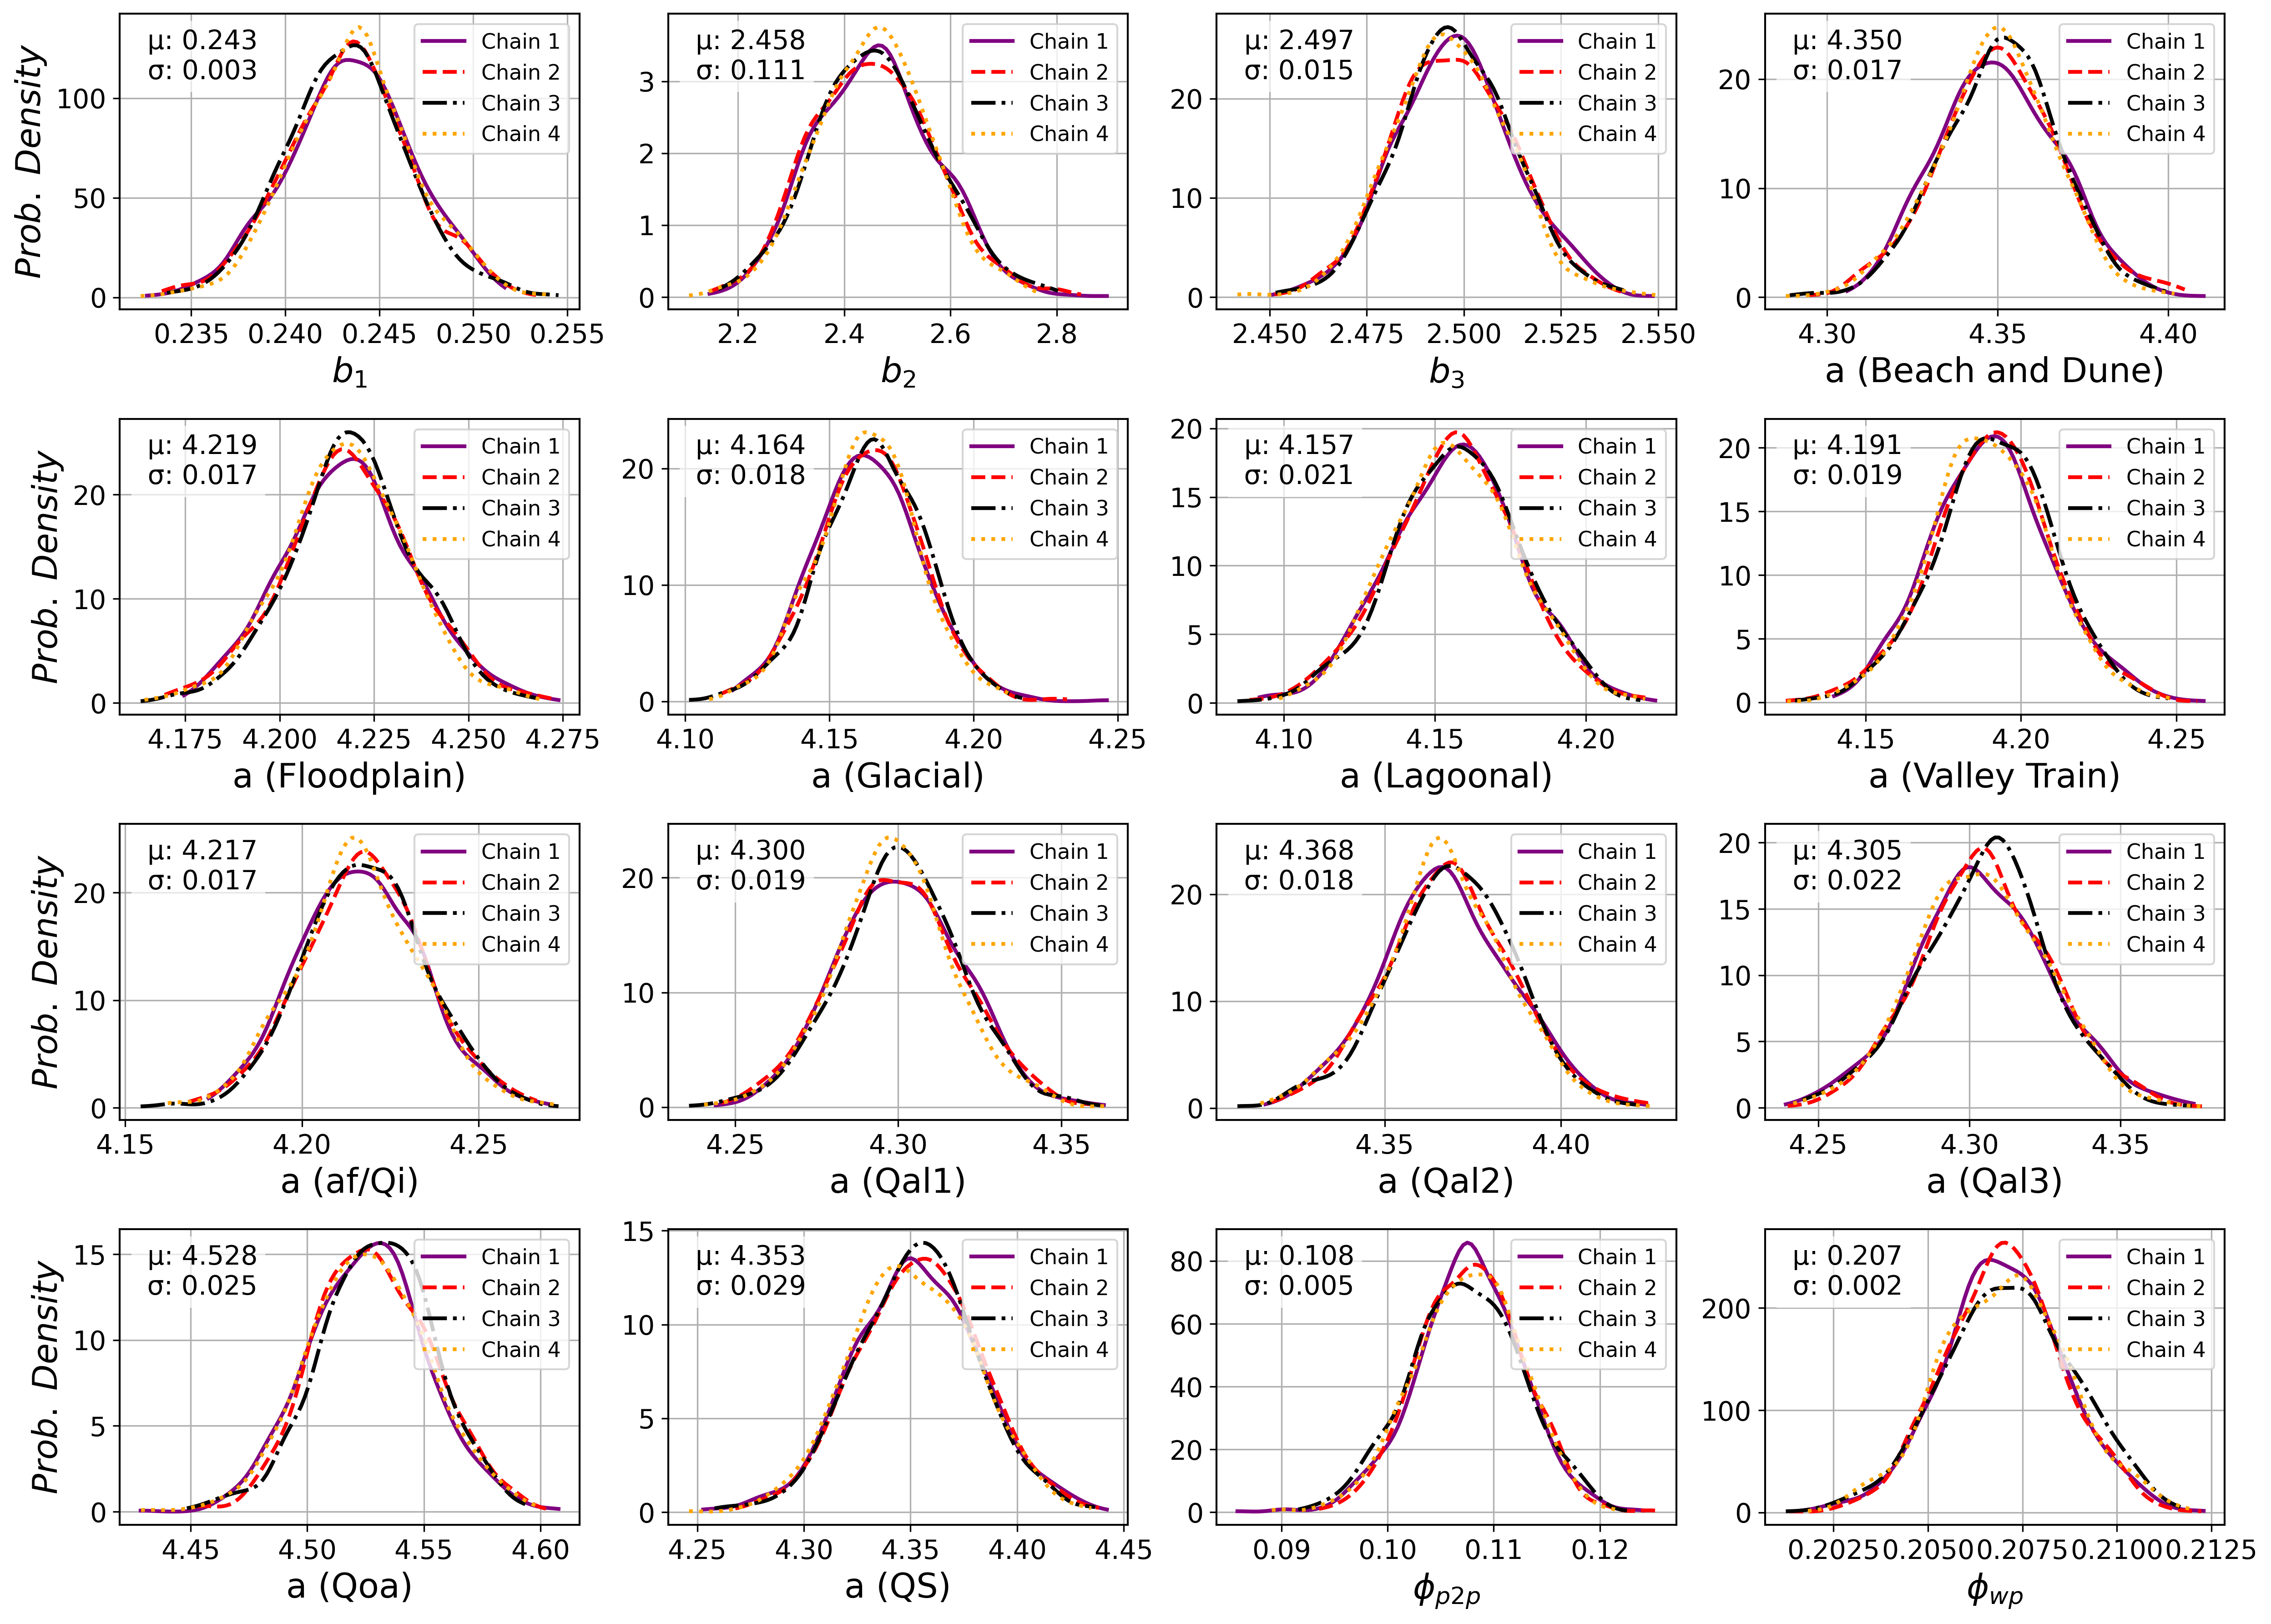

In [14]:

# Extract posterior samples as a DataFrame
posterior_samples = trace.posterior.to_dataframe()

# List of parameters you want to plot
params = ["b1", "b2", "b3", "a1", "a2", "a3", "a4", "a5", "a6", "a7", "a8", "a9", "a10", "a11", "sigma_p", "eps"]
linestyle=['solid','dashed','dashdot','dotted']
color=['purple','red','black','orange']
label=['Chain 1','Chain 2','Chain 3','Chain 4']

fig,ax=plt.subplots(4, 4, figsize=(16.5,12), dpi = 300)

ax=ax.flat

for j in range(0,len(params)):
    for i in range(0,4):
        kde=gaussian_kde(trace.posterior[params[j]][i])
        x_values = np.linspace(min(trace.posterior[params[j]][i]), max(trace.posterior[params[j]][i]), 100)
        density=kde(x_values)
        ax[j].plot(x_values, density, color=color[i], linewidth=2,linestyle=linestyle[i],label=label[i])
    annotation_text = f"μ: {trace.posterior[params[j]].mean():.3f}\n σ: {trace.posterior[params[j]].std():.3f}"

    # if j in [2,4,8,9,10]:
    ax[j].text(0.3, 0.95, annotation_text, transform=ax[j].transAxes,fontsize=14, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
#     elif j in [0,3]:
#         ax[j].text(0.3, 0.5, annotation_text, transform=ax[j].transAxes,fontsize=14, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
#     else:
#         ax[j].text(0.3, 0.95, annotation_text, transform=ax[j].transAxes,fontsize=14, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
   
   
    ax[j].legend(fontsize=11,loc='upper right')
    ax[j].grid()
    for spine in ax[j].spines.values():
        spine.set_linewidth(1)
    ax[j].tick_params(axis='both',labelsize=14)

ax[0].set_xlabel(r'$b_1$',fontsize=18)
ax[1].set_xlabel(r'$b_2$',fontsize=18)
ax[2].set_xlabel(r'$b_3$',fontsize=18)
ax[3].set_xlabel('a (Beach and Dune)',fontsize=18)
ax[4].set_xlabel('a (Floodplain)',fontsize=18)
ax[5].set_xlabel('a (Glacial)',fontsize=18)
ax[6].set_xlabel('a (Lagoonal)',fontsize=18)
ax[7].set_xlabel('a (Valley Train)',fontsize=18)
ax[8].set_xlabel('a (af/Qi)',fontsize=18)
ax[9].set_xlabel('a (Qal1)',fontsize=18)
ax[10].set_xlabel('a (Qal2)',fontsize=18)
ax[11].set_xlabel('a (Qal3)',fontsize=18)
ax[12].set_xlabel('a (Qoa)',fontsize=18)
ax[13].set_xlabel('a (QS)',fontsize=18)

ax[14].set_xlabel(r'$\phi_{p2p}$',fontsize=18)
ax[15].set_xlabel(r'$\phi_{wp}$',fontsize=18)

ax[0].set_ylabel('$Prob. \;Density$',fontsize=18)
ax[4].set_ylabel('$Prob. \;Density$',fontsize=18)
ax[8].set_ylabel('$Prob. \;Density$',fontsize=18)
ax[12].set_ylabel('$Prob. \;Density$',fontsize=18)

plt.tight_layout()
plt.savefig('Posteriors.jpg',dpi = 300,bbox_inches='tight')